In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import numpy as np
from scipy.optimize import curve_fit
from scipy.stats import kurtosis
import xarray as xr
import regionmask as regmask
import matplotlib.pyplot as plt
import xclimate as xclim

In [3]:
rootdir = Path("/glade/work/bbuchovecky/fhist_ppe_analysis/proc/dist")

tmax_stats = xr.open_dataset(rootdir / "TREFMXAV_daily_stats_199501-201412.nc")
tmax_stats_goga = xr.open_dataset(rootdir / "GOGA2_TREFMXAV_R_daily_stats_199501-201412.nc")

nhd = xr.open_dataset(rootdir / "FHIST_TREFMXAV_JJA_daily_199501-201412_nhd.nc")

/glade/derecho/scratch/bbuchovecky/tmp/ipykernel_49659/4065935577.py:6: FutureWarning: In a future version, xarray will not decode the variable 'nhd' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  nhd = xr.open_dataset(rootdir / "FHIST_TREFMXAV_JJA_daily_199501-201412_nhd.nc")


In [3]:
thr = xr.open_dataset("/glade/work/bbuchovecky/fhist_ppe_analysis/proc/dist/FHIST_TREFMXAV_JJA_daily_199501-201412_nhd_thresholds.nc")
nhd = xr.open_dataset("/glade/work/bbuchovecky/fhist_ppe_analysis/proc/dist/FHIST_TREFMXAV_JJA_daily_199501-201412_nhd.nc")

/glade/derecho/scratch/bbuchovecky/tmp/ipykernel_58641/1064036839.py:2: FutureWarning: In a future version, xarray will not decode the variable 'nhd' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  nhd = xr.open_dataset("/glade/work/bbuchovecky/fhist_ppe_analysis/proc/dist/FHIST_TREFMXAV_JJA_daily_199501-201412_nhd.nc")


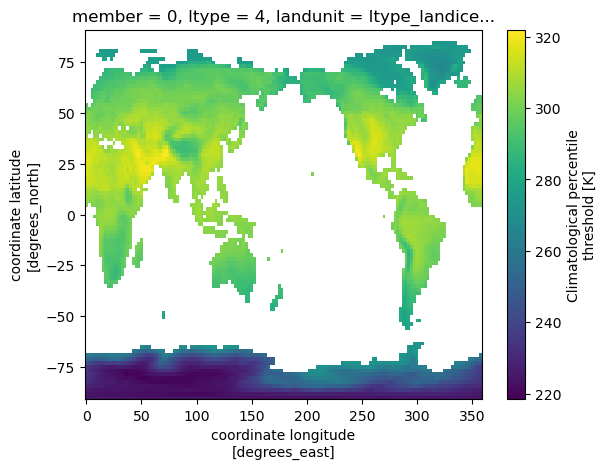

In [9]:
thr.thresholds.sel(member=0, quantile=0.95, dayofyear=180).plot()

In [4]:
nhd

<xarray.Dataset> Size: 179MB
Dimensions:   (member: 27, quantile: 3, year: 20, lat: 96, lon: 144)
Coordinates:
  * member    (member) int64 216B 0 1 2 3 4 5 6 7 8 ... 20 21 22 23 24 25 26 27
  * quantile  (quantile) float64 24B 0.9 0.95 0.99
  * year      (year) int64 160B 1995 1996 1997 1998 1999 ... 2011 2012 2013 2014
  * lat       (lat) float32 384B -90.0 -88.11 -86.21 -84.32 ... 86.21 88.11 90.0
  * lon       (lon) float32 576B 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
    ltype     int64 8B ...
    landunit  <U40 160B ...
Data variables:
    nhd       (member, quantile, year, lat, lon) timedelta64[ns] 179MB ...
Attributes:
    description:  (6, 7, 8) months heat-day counts
    nhd_method:   Raw temperature; per-member 5-day centered DOY-window perce...
    percentiles:  [0.9  0.95 0.99]
    window_days:  5
    dataset:      fhist

In [12]:
gc = dict(lat=45, lon=270, method='nearest')

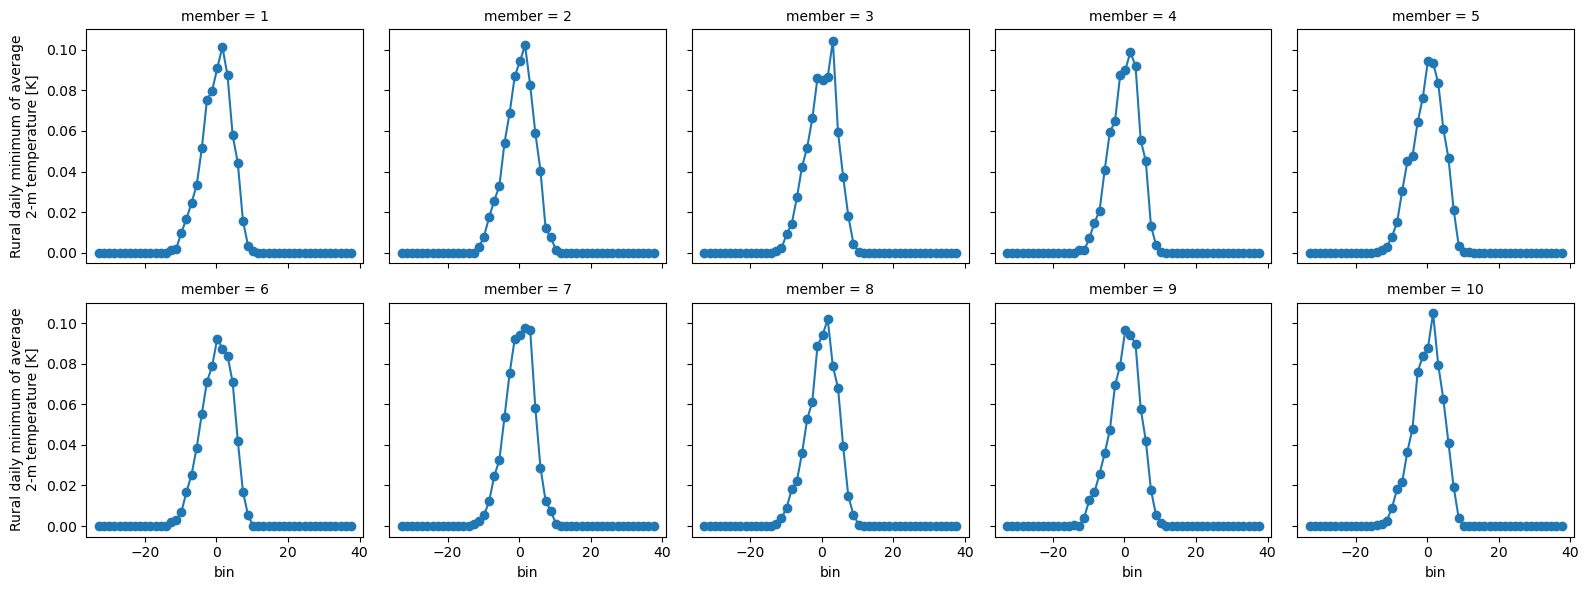

In [22]:
tmax_stats_goga.sel(**gc).histogram.plot(col='member', col_wrap=5, marker='o')

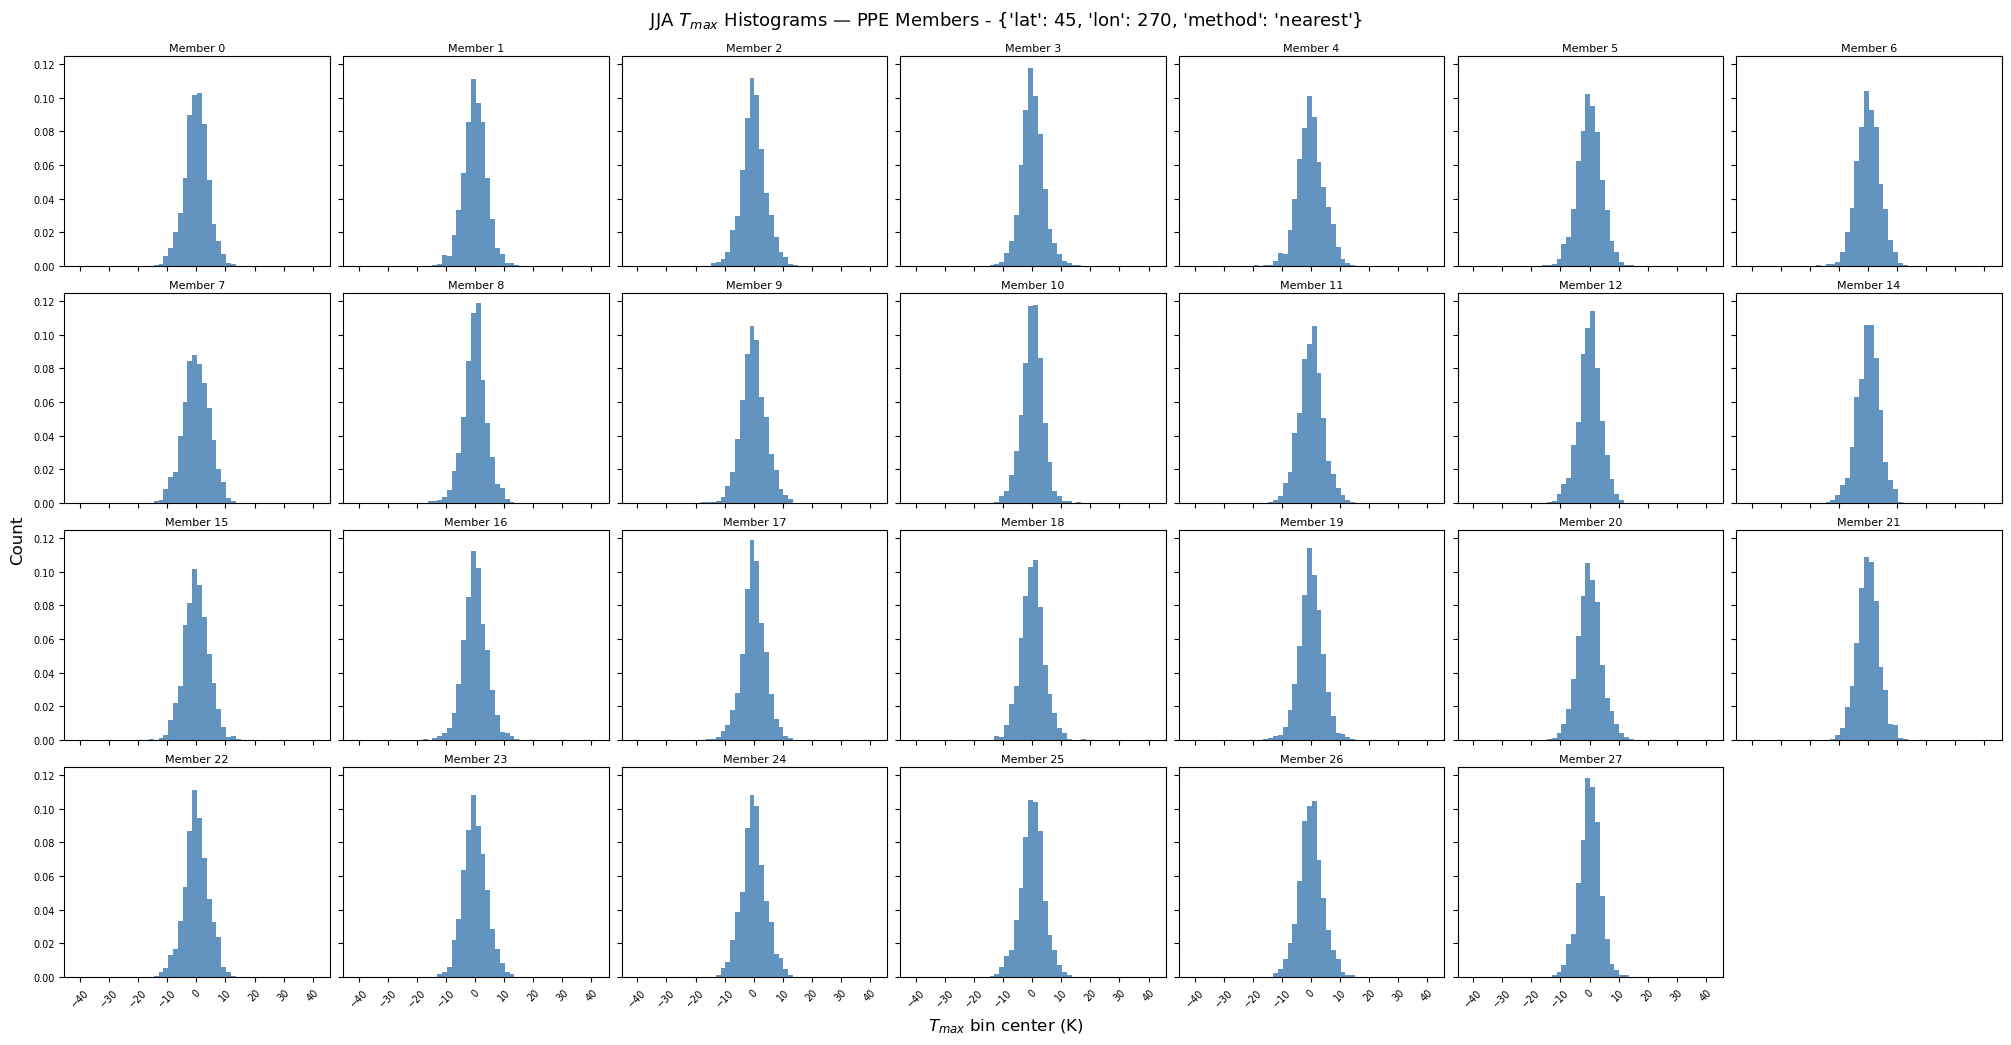

In [37]:
members    = tmax_stats['member'].values          # shape (27,)
bin_centers = tmax_stats['bin_center'].values     # shape (50,)
bin_width   = float(bin_centers[1] - bin_centers[0])  # assumes uniform spacing

ncols, nrows = 7, 4   # 28 panels ≥ 27 members
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 10),
                         sharex=True, sharey=True,
                         constrained_layout=True)
axes_flat = axes.flatten()

for i, mem in enumerate(members):
    ax = axes_flat[i]
    counts = tmax_stats.histogram.sel(**gc, member=int(mem)).values  # shape (50,)
    ax.bar(bin_centers, counts,
           width=bin_width, align='center',
           color='steelblue', edgecolor='none', alpha=0.85)
    ax.set_title(f'Member {mem}', fontsize=8, pad=3)

# Tick placement: every ~10 K to avoid crowding
tick_vals = np.arange(np.ceil(bin_centers[0] / 10) * 10,
                      bin_centers[-1] + 1, 10).astype(int)
for ax in axes_flat[:len(members)]:
    ax.set_xticks(tick_vals)
    ax.tick_params(axis='x', labelsize=7, rotation=45)
    ax.tick_params(axis='y', labelsize=7)

# Hide unused panels
for j in range(len(members), len(axes_flat)):
    axes_flat[j].set_visible(False)

# Shared axis labels
fig.supxlabel('$T_{max}$ bin center (K)', fontsize=12)
fig.supylabel('Count', fontsize=12)
fig.suptitle('JJA $T_{max}$ Histograms — PPE Members - '+str(gc), fontsize=13, y=1.03)

plt.savefig('member_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

Text(0.5, 1.0, 'GOGA2 abs(max(daily TREFMXAV_R skewness))')

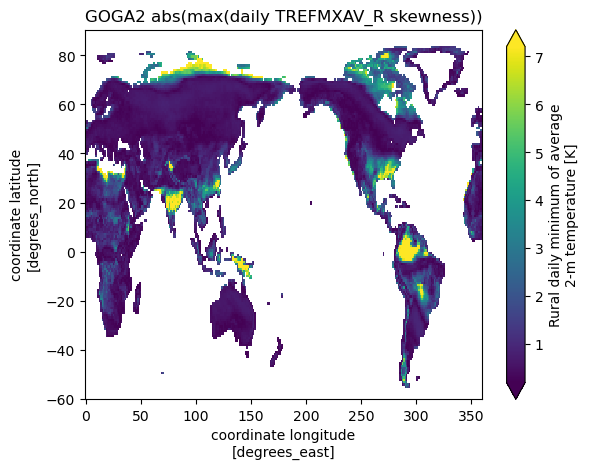

In [5]:
abs(tmax_stats_goga.kurtosis.sel(lat=slice(-60, None))).max(dim='member').plot(robust=True)
plt.title("GOGA2 abs(max(daily TREFMXAV_R skewness))")

Text(0.5, 1.0, 'PPE abs(max(daily TREFMXAV_R skewness))')

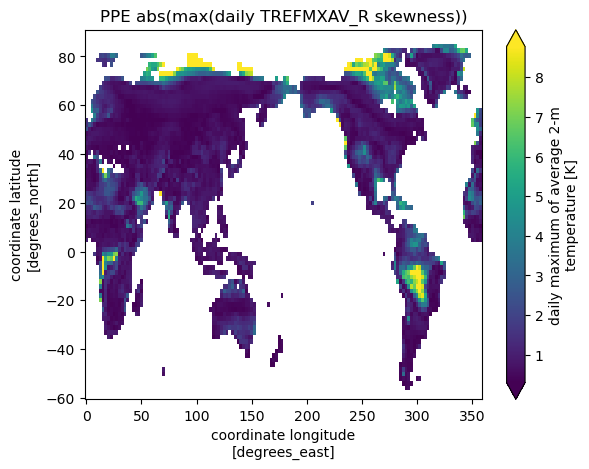

In [6]:
abs(tmax_stats.kurtosis.sel(lat=slice(-60, None))).max(dim='member').plot(robust=True)
plt.title("PPE abs(max(daily TREFMXAV_R skewness))")

Text(0.5, 1.0, 'GOGA2 abs(max(daily TREFMXAV_R kurtosis))')

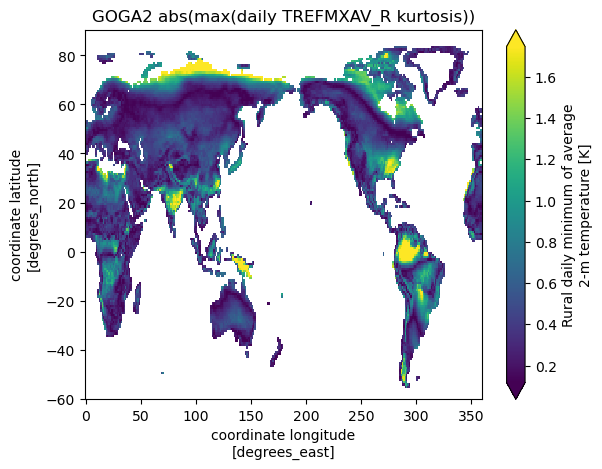

In [9]:
abs(tmax_stats_goga.skewness.sel(lat=slice(-60, None))).max(dim='member').plot(robust=True)
plt.title("GOGA2 abs(max(daily TREFMXAV_R kurtosis))")

Text(0.5, 1.0, 'PPE abs(max(daily TREFMXAV_R kurtosis))')

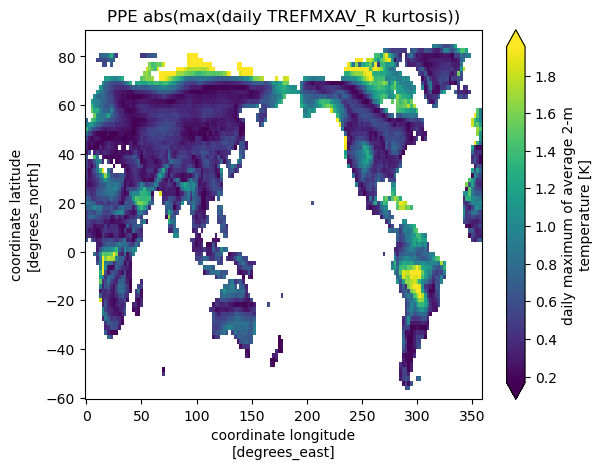

In [10]:
abs(tmax_stats.skewness.sel(lat=slice(-60, None))).max(dim='member').plot(robust=True)
plt.title("PPE abs(max(daily TREFMXAV_R kurtosis))")

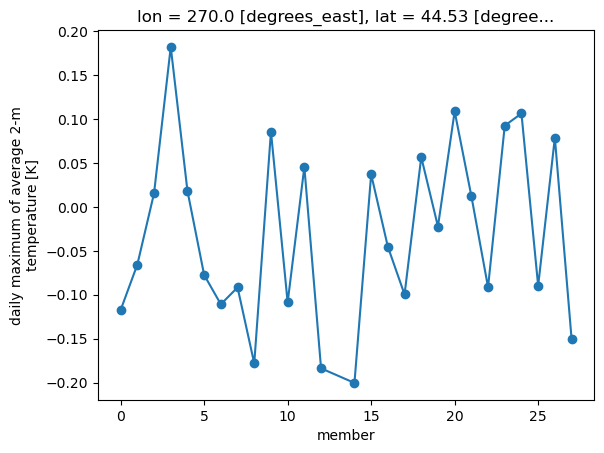

In [14]:
tmax_stats.skewness.sel(**gc).plot(marker='o')

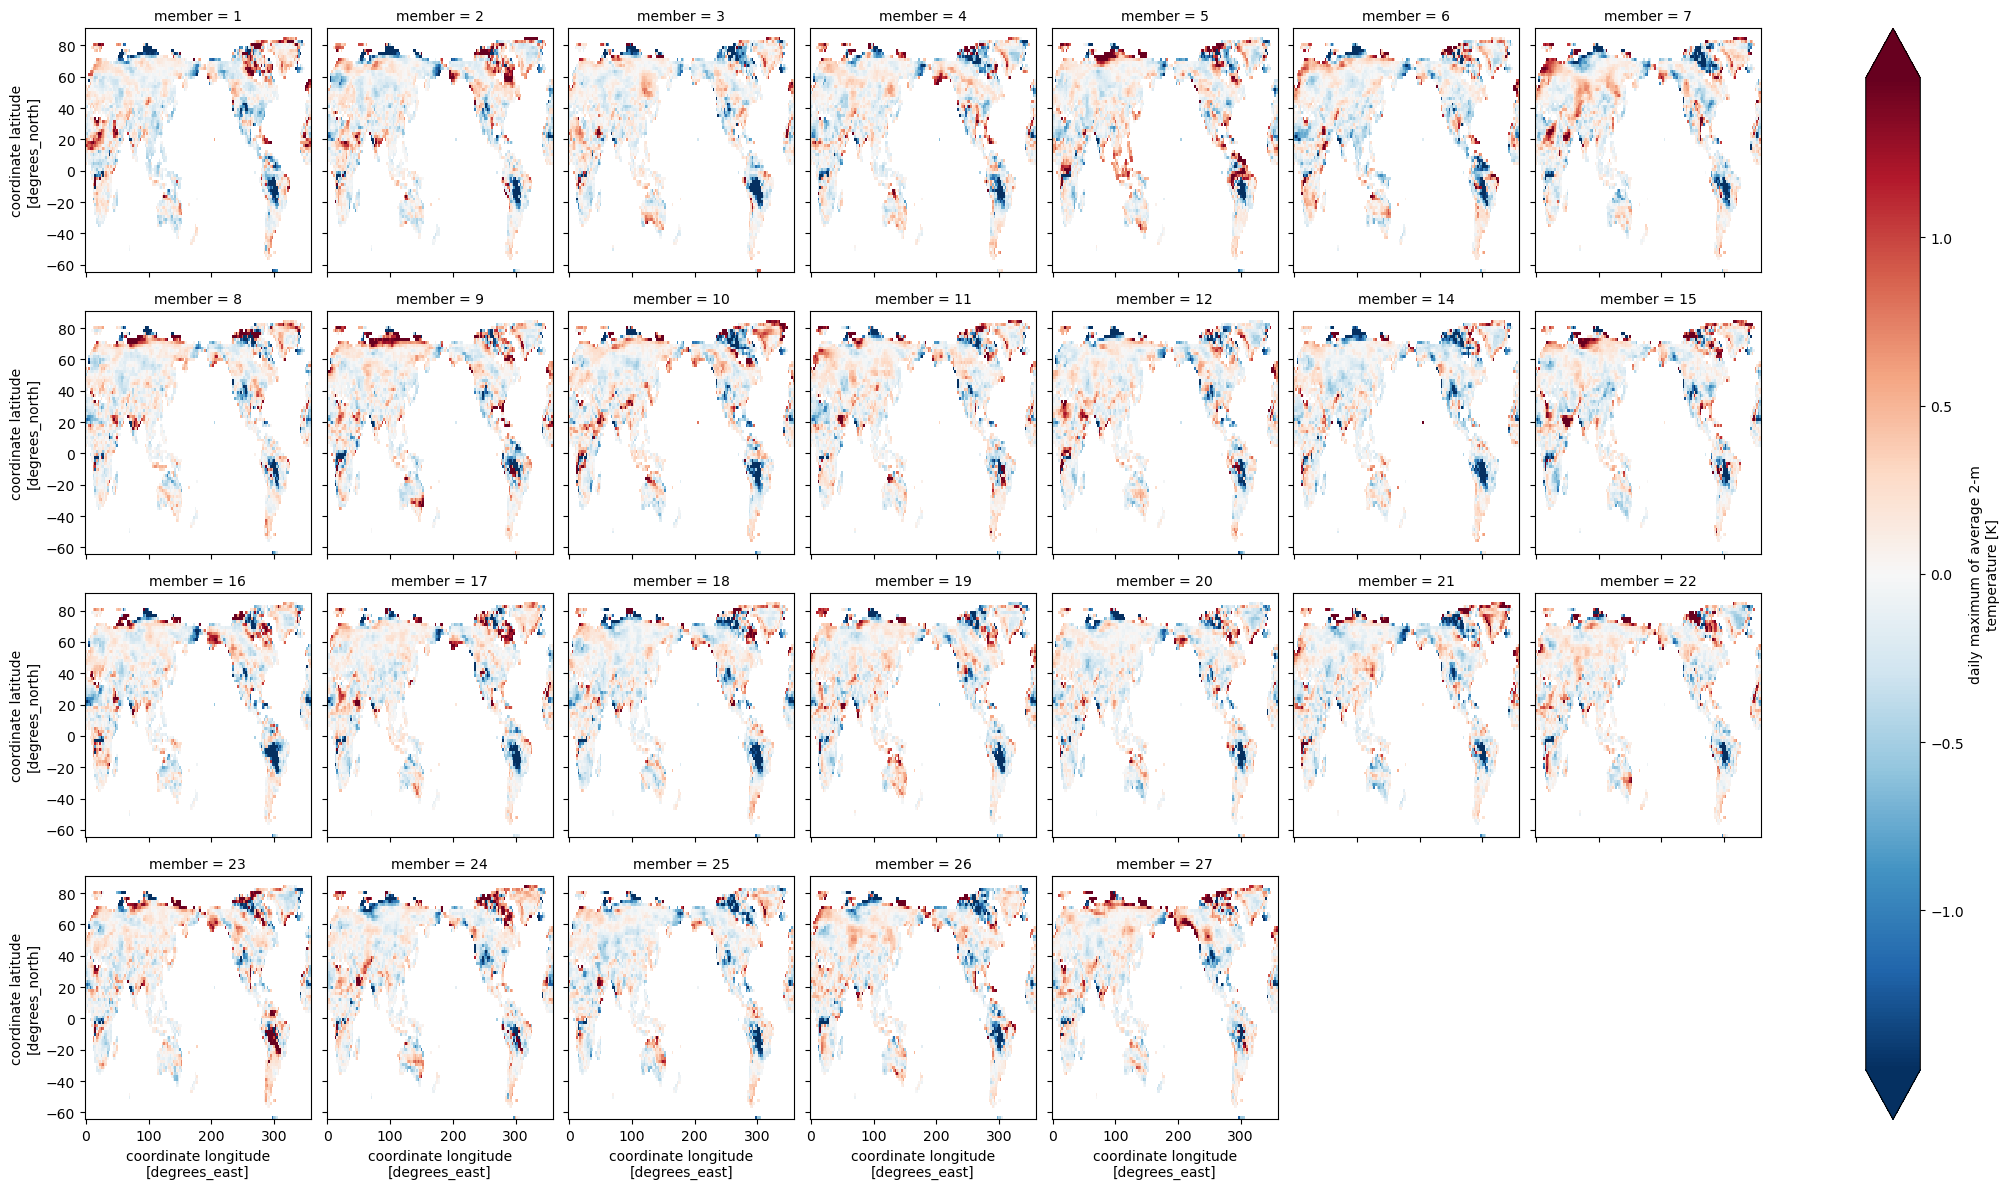

In [19]:
(tmax_stats.kurtosis.sel(member=slice(1, None)) - tmax_stats.kurtosis.sel(member=0)).sel(lat=slice(-65, None)).plot(col='member', col_wrap=7, robust=True)

In [3]:
def gaussian(x, amplitude, mean, sigma, offset):
    return amplitude * np.exp(-0.5 * ((x - mean) / sigma) ** 2) + offset


def fit_gaussian_to_histogram(
    da: xr.DataArray,
    bins: int | np.ndarray = 50,
    density: bool = False,
    p0: tuple[float, float, float, float] | None = None,
    bounds: tuple[tuple[float, ...], tuple[float, ...]] | None = None,
    maxfev: int = 10000,
) -> tuple[xr.DataArray, xr.DataArray, xr.DataArray, xr.DataArray]:
    """Fit a Gaussian to the histogram of a 1D DataArray.

    Parameters
    ----------
    da
        Input timeseries DataArray. All values are flattened before fitting.
    bins
        Number of bins or explicit bin edges passed to numpy.histogram.
    density
        If True, fit the probability density instead of counts.
    p0
        Optional initial parameter guess as (amplitude, mean, sigma, offset).
    bounds
        Optional curve_fit bounds.
    maxfev
        Maximum number of function evaluations for curve_fit.

    Returns
    -------
    bin_centers, hist, fitted_curve, params
        Bin centers as a DataArray, empirical bin heights at those centers,
        fitted Gaussian evaluated at those centers, and the best-fit parameters
        as a labeled DataArray.
    """

    values = np.asarray(da.values, dtype=float).ravel()
    values = values[np.isfinite(values)]

    if values.size < 4:
        raise ValueError("Need at least four finite values to fit a histogram Gaussian")

    hist, bin_edges = np.histogram(values, bins=bins, density=density)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    if p0 is None:
        offset0 = float(np.nanmin(hist))
        amplitude0 = float(np.nanmax(hist) - offset0)
        if not np.isfinite(amplitude0) or amplitude0 == 0:
            amplitude0 = 1.0
        mean0 = float(np.nanmean(values))
        sigma0 = float(np.nanstd(values))
        if not np.isfinite(sigma0) or sigma0 == 0:
            sigma0 = max(float(np.ptp(values)) / 6.0, 1.0)
        p0 = (amplitude0, mean0, sigma0, offset0)

    if bounds is None:
        lower = (-np.inf, np.min(values), 0.0, -np.inf)
        upper = (np.inf, np.max(values), np.inf, np.inf)
        bounds = (lower, upper)

    params, _ = curve_fit(
        gaussian,
        bin_centers,
        hist,
        p0=p0,
        bounds=bounds,
        maxfev=maxfev,
    )
    fitted = gaussian(bin_centers, *params)
    param_names = ["amplitude", "mean", "sigma", "offset"]
    params_da = xr.DataArray(
        params,
        dims=("param",),
        coords={"param": param_names},
        name="gaussian_params",
    )

    center_da = xr.DataArray(bin_centers, dims=("bin",), name="bin_center")
    hist_da = xr.DataArray(hist, dims=("bin",), coords={"bin": center_da}, name="hist")
    fit_da = xr.DataArray(fitted, dims=("bin",), coords={"bin": center_da}, name="fitted")
    return center_da, hist_da, fit_da, params_da


def fit_gaussian_histogram_along_dim(
    da: xr.DataArray,
    group_dim: str = "member",
    time_dim: str = "time",
    bins: int | np.ndarray = 50,
    density: bool = False,
    p0: tuple[float, float, float, float] | None = None,
    bounds: tuple[tuple[float, ...], tuple[float, ...]] | None = None,
    maxfev: int = 10000,
) -> tuple[xr.DataArray, xr.DataArray, xr.DataArray, xr.DataArray]:
    """Compute a histogram over `time_dim` for each slice across `group_dim` and fit a Gaussian.

    Returns:
      (bin_centers, hist_da, fit_da, params_da)

    - `params_da` has dims `(group_dim, param)` with labels
      `('amplitude','mean','sigma','offset')`.
    - `hist_da` and `fit_da` have dims `(group_dim, bin)` with a shared
      `bin` coordinate of bin centers.

    The function works with dask-backed arrays via `xr.apply_ufunc`.
    """

    # Decide common bin edges so histograms are comparable across groups
    if isinstance(bins, (int, np.integer)):
        pooled = np.asarray(da.values, dtype=float).ravel()
        pooled = pooled[np.isfinite(pooled)]
        if pooled.size < 4:
            raise ValueError("Need at least four finite values to compute global bin edges")
        edges = np.histogram_bin_edges(pooled, bins=bins)
    else:
        edges = np.asarray(bins)

    centers = 0.5 * (edges[:-1] + edges[1:])

    def _fit_all(v1d):
        vals = np.asarray(v1d, dtype=float).ravel()
        vals = vals[np.isfinite(vals)]
        if vals.size < 4:
            return (
                np.array([np.nan, np.nan, np.nan, np.nan], dtype=float),
                centers.astype(float),
                np.full_like(centers, np.nan, dtype=float),
                np.full_like(centers, np.nan, dtype=float),
            )

        hist = np.histogram(vals, bins=edges, density=density)[0]

        # sensible defaults
        if p0 is None:
            offset0 = float(np.nanmin(hist))
            amplitude0 = float(np.nanmax(hist) - offset0)
            if not np.isfinite(amplitude0) or amplitude0 == 0:
                amplitude0 = 1.0
            mean0 = float(np.nanmean(vals))
            sigma0 = float(np.nanstd(vals))
            if not np.isfinite(sigma0) or sigma0 == 0:
                sigma0 = max(float(np.ptp(vals)) / 6.0, 1.0)
            p0_local = (amplitude0, mean0, sigma0, offset0)
        else:
            p0_local = p0

        if bounds is None:
            lower = (-np.inf, np.min(vals), 0.0, -np.inf)
            upper = (np.inf, np.max(vals), np.inf, np.inf)
            bounds_local = (lower, upper)
        else:
            bounds_local = bounds

        try:
            params, _ = curve_fit(
                gaussian,
                centers,
                hist,
                p0=p0_local,
                bounds=bounds_local,
                maxfev=maxfev,
            )
            fitted = gaussian(centers, *params)
            return params.astype(float), centers.astype(float), hist.astype(float), fitted.astype(float)
        except Exception:
            return (
                np.array([np.nan, np.nan, np.nan, np.nan], dtype=float),
                centers.astype(float),
                hist.astype(float),
                np.full_like(centers, np.nan, dtype=float),
            )

    params_da, centers_dummy, hist_da, fit_da = xr.apply_ufunc(
        _fit_all,
        da,
        input_core_dims=[[time_dim]],
        output_core_dims=[["param"], ["bin"], ["bin"], ["bin"]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float, float, float, float],
        output_sizes={"param": 4, "bin": centers.size},
    )

    # centers are identical across groups; make a single 1D coordinate
    bin_centers_da = xr.DataArray(centers, dims=("bin",), name="bin_center")

    params_da = params_da.assign_coords(param=("param", ["amplitude", "mean", "sigma", "offset"]))
    params_da.name = "gaussian_params"

    # attach bin coords to hist and fit
    hist_da = hist_da.assign_coords(bin=bin_centers_da)
    hist_da.name = "hist"
    fit_da = fit_da.assign_coords(bin=bin_centers_da)
    fit_da.name = "fitted"

    return bin_centers_da, hist_da, fit_da, params_da


def fit_gaussian_along_dim(
    da: xr.DataArray,
    dim: str,
    coord: xr.DataArray | np.ndarray | None = None,
    p0: tuple[float, float, float, float] | None = None,
    bounds: tuple[tuple[float, ...], tuple[float, ...]] | None = None,
    maxfev: int = 10000,
) -> xr.DataArray:
    """Backward-compatible wrapper for fitting along a dimension.

    For a timeseries histogram fit, use `fit_gaussian_to_histogram` or
    `fit_gaussian_histogram_along_dim` instead.
    """

    if coord is None:
        if dim in da.coords:
            x = da[dim]
            if np.issubdtype(x.dtype, np.number):
                coord = x
            else:
                coord = xr.DataArray(np.arange(da.sizes[dim]), dims=(dim,))
        else:
            coord = xr.DataArray(np.arange(da.sizes[dim]), dims=(dim,))
    elif not isinstance(coord, xr.DataArray):
        coord = xr.DataArray(np.asarray(coord), dims=(dim,))

    coord = coord.astype(float)

    def _fit_one(y, x):
        y = np.asarray(y, dtype=float)
        x = np.asarray(x, dtype=float)
        mask = np.isfinite(x) & np.isfinite(y)

        if mask.sum() < 4:
            return np.full_like(y, np.nan, dtype=float)

        x_fit = x[mask]
        y_fit = y[mask]

        if p0 is None:
            offset0 = np.nanmin(y_fit)
            amplitude0 = np.nanmax(y_fit) - offset0
            if not np.isfinite(amplitude0) or amplitude0 == 0:
                amplitude0 = 1.0
            mean0 = x_fit[np.nanargmax(y_fit)]
            sigma0 = np.nanstd(x_fit)
            if not np.isfinite(sigma0) or sigma0 == 0:
                sigma0 = max(np.ptp(x_fit) / 6.0, 1.0)
            p0_local = (amplitude0, mean0, sigma0, offset0)
        else:
            p0_local = p0

        if bounds is None:
            lower = (-np.inf, np.min(x_fit), 0.0, -np.inf)
            upper = (np.inf, np.max(x_fit), np.inf, np.inf)
            bounds_local = (lower, upper)
        else:
            bounds_local = bounds

        try:
            params, _ = curve_fit(
                gaussian,
                x_fit,
                y_fit,
                p0=p0_local,
                bounds=bounds_local,
                maxfev=maxfev,
            )
            return gaussian(x, *params)
        except Exception:
            return np.full_like(y, np.nan, dtype=float)

    return xr.apply_ufunc(
        _fit_one,
        da,
        coord,
        input_core_dims=[[dim], [dim]],
        output_core_dims=[[dim]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
    )


In [20]:
def kurtosis_along_dim(
    da: xr.DataArray,
    dim: str = "time",
    fisher: bool = True,
    bias: bool = True,
    nan_policy: str = "propagate",
) -> xr.DataArray:
    """Apply scipy.stats.kurtosis along a named dimension.

    Parameters
    ----------
    da
        Input DataArray.
    dim
        Dimension to reduce over.
    fisher
        If True, return Fisher's definition of kurtosis (normal == 0).
        If False, return Pearson's definition (normal == 3).
    bias
        If False, apply bias correction.
    nan_policy
        How to handle NaNs: 'propagate', 'omit', or 'raise'.
    """

    return xr.apply_ufunc(
        kurtosis,
        da,
        input_core_dims=[[dim]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
        kwargs={
            "axis": -1,
            "fisher": fisher,
            "bias": bias,
            "nan_policy": nan_policy,
        },
    )


In [4]:
time_slice = slice("1995-01", "2014-12")
year_start = time_slice.start[:4]
year_end = time_slice.stop[:4]
variables = [
## monthly output:
    # "SMP_month_1",
    # "SOILLIQ_month_1",
    # "SOILWATER_10CM_month_1",
    # "BTRANMN_month_1",

## daily output:
    # "SMP_day_1",
    # "BTRANMN_day_1",
    # "SOILWATER_10CM_day_1",
    "TREFMXAV_day_1",
    # "TREFMNAV_day_1",
    "TREFHT_day_1",
]

members = [0, 7]

In [5]:
client_cluster = xclim.create_dask_cluster(
    account='UWAS0155',
    nworkers=4,
    ncores=2,
    nmem='32GB',
    walltime='01:00:00'
)

account:  UWAS0155
nworkers: 4
ncores:   2
nmemory:  32GB
walltime: 01:00:00


/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 40205 instead
  warnings.warn(


{}

To view the dask dashboard
Run the following command in your local terminal:
> ssh -N -L 40205:128.117.211.161:40205 bbuchovecky@casper.hpc.ucar.edu
Open the following link in your local browser:
> http://localhost:40205/status


In [6]:
client_cluster[0].wait_for_workers(4)

In [7]:
# xclim.close_dask_cluster(client_cluster)

# Load FHIST

In [8]:
grid = xclim.load_fhist_ppe_grid()

fhist = {}
for v in variables:
    print(v)
    vv = "_".join(v.split("_")[:-2])
    fhist[v] = (
        xclim.load_fhist(
            v,
            keep_var_only=True,
        )[vv]
        .sel(time=time_slice)
        .reindex_like(grid, method="nearest", tolerance=1e-3)
        .where(grid.LANDFRAC > 0)
        .chunk({'time': 1825, 'member': 1, 'lon': -1, 'lat': -1})
    )

TREFMXAV_day_1
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
27
TREFHT_day_1
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
27


In [9]:
tmax = fhist['TREFMXAV_day_1'].sel(member=members)

In [10]:
tmax_anom = tmax.groupby('time.dayofyear') - tmax.groupby('time.dayofyear').mean()
tmax_anom_jja = tmax_anom.sel(time=tmax_anom.time.dt.month.isin([6, 7, 8]))

In [11]:
tmax_anom_jja_mu = tmax_anom_jja.mean(dim='time').compute()
tmax_anom_jja_sigma = tmax_anom_jja.std(dim='time').compute()

/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 111.67 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 111.67 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [12]:
tmax_anom_jja_fit = fit_gaussian_histogram_along_dim(
    tmax_anom_jja.chunk({'time': -1}),
    density=True,
)

/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 111.67 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/glade/derecho/scratch/bbuchovecky/tmp/ipykernel_91038/2737066621.py:174: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  params_da, centers_dummy, hist_da, fit_da = xr.apply_ufunc(


In [13]:
tmax_anom_jja_fit_bins, tmax_anom_jja_hist, tmax_anom_jja_fit, tmax_anom_jja_params = tmax_anom_jja_fit[0].compute(), tmax_anom_jja_fit[1].compute(), tmax_anom_jja_fit[2].compute(), tmax_anom_jja_fit[3].compute()

/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 111.68 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [55]:
gc = dict(lat=-10, lon=300, method='nearest')

In [56]:
tmax_anom_jja_mu.sel(member=0, **gc).values

array(-9.453815e-07, dtype=float32)

In [57]:
tmax_anom_jja_mu.sel(member=7, **gc).values

array(-2.3385753e-06, dtype=float32)

In [58]:
tmax_anom_jja_sigma.sel(member=0, **gc).values

array(1.3268316, dtype=float32)

In [59]:
tmax_anom_jja_sigma.sel(member=7, **gc).values

array(1.5481207, dtype=float32)

In [60]:
tmax_anom_jja_params.sel(member=7, **gc)

<xarray.DataArray 'gaussian_params' (param: 4)> Size: 32B
array([ 2.51129848e-01,  5.39981171e-02,  1.59336641e+00, -4.32448377e-05])
Coordinates:
  * param    (param) <U9 144B 'amplitude' 'mean' 'sigma' 'offset'
    lon      float64 8B 300.0
    lat      float64 8B -10.42
    member   int64 8B 7
Attributes:
    long_name:     daily maximum of average 2-m temperature
    units:         K
    cell_methods:  time: mean

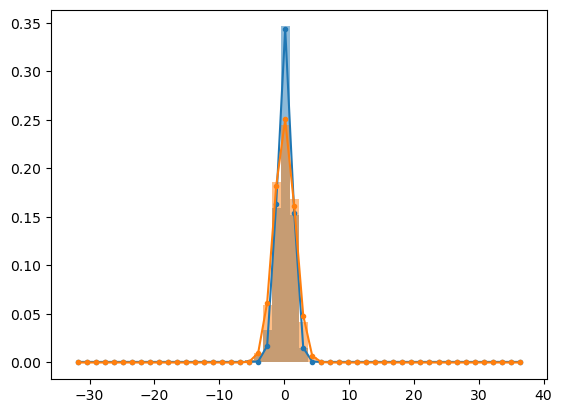

In [61]:
plt.bar(
    tmax_anom_jja_fit_bins,
    tmax_anom_jja_hist.sel(member=0, **gc),
    width = tmax_anom_jja_fit_bins.diff(dim='bin')[0],
    alpha=0.5
)
plt.plot(
    tmax_anom_jja_fit_bins,
    tmax_anom_jja_fit.sel(member=0, **gc),
    color='tab:blue',
    marker='.',
)

plt.bar(
    tmax_anom_jja_fit_bins,
    tmax_anom_jja_hist.sel(member=7, **gc),
    width = tmax_anom_jja_fit_bins.diff(dim='bin')[0],
    alpha=0.5
)
plt.plot(
    tmax_anom_jja_fit_bins,
    tmax_anom_jja_fit.sel(member=7, **gc),
    color='tab:orange',
    marker='.',
)

In [24]:
kts = kurtosis_along_dim(tmax_anom_jja.chunk({'time': -1}), dim='time').compute()

/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 111.67 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [23]:
kts

<xarray.DataArray 'TREFMXAV' (member: 2, lat: 96, lon: 144)> Size: 221kB
dask.array<transpose, shape=(2, 96, 144), dtype=float64, chunksize=(1, 96, 144), chunktype=numpy.ndarray>
Coordinates:
  * member   (member) int64 16B 0 7
  * lat      (lat) float64 768B -90.0 -88.11 -86.21 -84.32 ... 86.21 88.11 90.0
  * lon      (lon) float64 1kB 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
Attributes:
    long_name:     daily maximum of average 2-m temperature
    units:         K
    cell_methods:  time: mean

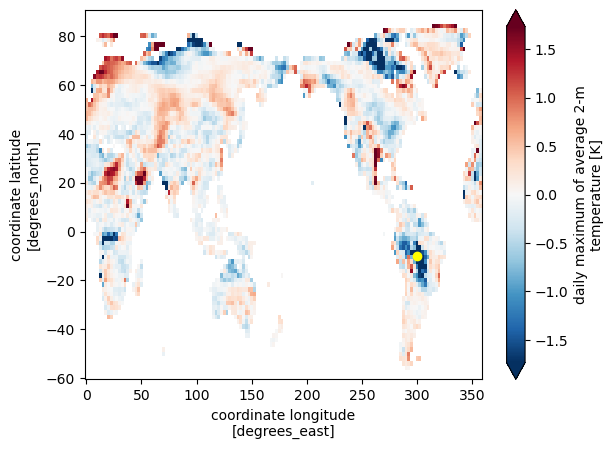

In [54]:
(kts.sel(member=7) - kts.sel(member=0)).sel(lat=slice(-60, None)).plot(robust=True)
plt.plot(300, -10, color='yellow', marker='o')

In [62]:
kts.sel(member=7, **gc)

<xarray.DataArray 'TREFMXAV' ()> Size: 8B
array(0.68252707)
Coordinates:
    lon      float64 8B 300.0
    lat      float64 8B -10.42
    member   int64 8B 7
Attributes:
    long_name:     daily maximum of average 2-m temperature
    units:         K
    cell_methods:  time: mean

In [63]:
kts.sel(member=0, **gc)

<xarray.DataArray 'TREFMXAV' ()> Size: 8B
array(7.76900768)
Coordinates:
    lon      float64 8B 300.0
    lat      float64 8B -10.42
    member   int64 8B 0
Attributes:
    long_name:     daily maximum of average 2-m temperature
    units:         K
    cell_methods:  time: mean

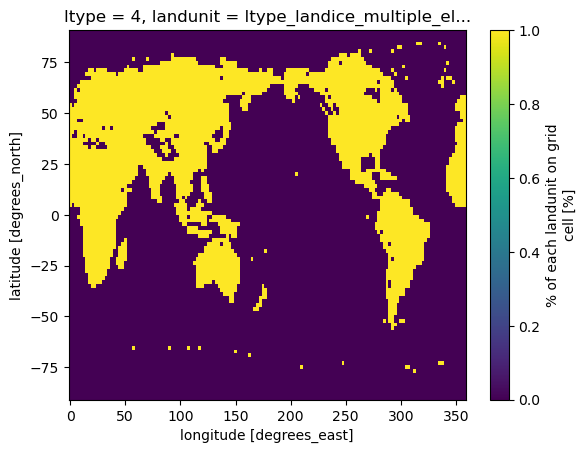

In [69]:
(grid.PCT_GLC == 0).plot()